In [1]:
!pip install transformers

In [2]:
import torch

from transformers import BertTokenizer
from transformers import BertModel

In [3]:
#LOADING PRETRAINED BERT

#bert-base-uncased : bert, base: 12 transformer layers, uncased for lowercase
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

bert_model = BertModel.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
sample_news = """Scientists have announced a breakthrough in renewable energy technology."""

#basic wording tockenization with CLS at start and SEP for seperating
#then converting these tokens to vocabulary ID
#bert never sees words but as numbers
tokens = bert_tokenizer(
    sample_news,
    return_tensors="pt",
    padding=True,
    truncation=True
)

for i in tokens :
  print(i , ":")
  print(tokens[i])
  print()

input_ids :
tensor([[  101,  6529,  2031,  2623,  1037, 12687,  1999, 13918,  2943,  2974,
          1012,   102]])

token_type_ids :
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

attention_mask :
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])



In [5]:
#tokens oased through BERT to convert the ID's to embeddings
with torch.no_grad() :        #not training just using it
    outputs = bert_model(**tokens)

#1 sentence, 12 tokens, 768-dimensional embedding
print(outputs.last_hidden_state.shape)

torch.Size([1, 12, 768])


In [6]:
#extracting cls embedding
cls_embedding = outputs.last_hidden_state[:, 0, :]

print(cls_embedding.shape)

torch.Size([1, 768])


In [7]:
bert_classifier = torch.nn.Sequential(
    torch.nn.Linear(768, 128),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.3),
    torch.nn.Linear(128, 2) )

In [8]:
output = bert_classifier(cls_embedding)

print(output)

tensor([[-0.0272,  0.0032]], grad_fn=<AddmmBackward0>)


In [9]:
prediction = torch.argmax(output, dim=1)

print(prediction)

tensor([1])


In [ ]:
### APPLYING BERT ON REAL NEWS ARTICLES helps in contextual embeddings ulike TF-IDF

In [18]:
import pandas as pd
import zipfile


with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall()

fake_dataset = pd.read_csv("Fake.csv")
true_dataset = pd.read_csv("True.csv")

fake_dataset["label"] = 0
true_dataset["label"] = 1

#concatenate the dataset
dataset = pd.concat([fake_dataset, true_dataset],
    axis=0)

# shuffle the dataset
dataset = dataset.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [24]:
#concatenating content, title, text
dataset["content"] = (
    dataset["title"]
    + " "
    + dataset["text"])

#running bert on reduced dataset
reduced_dataset = dataset.iloc[:100]

print(reduced_dataset.shape)

reduced_dataset.head()

(100, 6)


,title,text,subject,date,label,content
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,Ben Stein Calls Out 9th Circuit Court: Committ...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,Trump drops Steve Bannon from National Securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,Puerto Rico expects U.S. to lift Jones Act shi...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,OOPS: Trump Just Accidentally Confirmed He Le...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,Donald Trump heads for Scotland to reopen a go...


In [25]:
#picking any one real articles
news_text = reduced_dataset["content"][0]

print(news_text[:500])

Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washingto


In [26]:
#tokenising the article
tokens_article = bert_tokenizer(
    news_text,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=512
)

#getting embedding using bert model
with torch.no_grad():
    outputs = bert_model(**tokens_article)

In [27]:
cls_embedding_article = outputs.last_hidden_state[:,0,:]

print(cls_embedding_article.shape)

torch.Size([1, 768])


In [28]:
embeddings = []

for each_article in reduced_dataset["content"] :
  each_tokens = bert_tokenizer(each_article, return_tensors="pt", padding=True, truncation=True, max_length=512)

  with torch.no_grad():
    each_embeddings = bert_model(**each_tokens)

    cls_embedding_each = each_embeddings.last_hidden_state[:,0,:]
    embeddings.append(cls_embedding_each.squeeze(0).numpy())


In [29]:
print("Number of embeddings :", len(embeddings))

print("Shape of first embedding :")

print(embeddings[0].shape)

Number of embeddings : 100
Shape of first embedding :
(768,)


In [31]:
import numpy as np

X = np.array(embeddings)

y = reduced_dataset["label"].values

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [41]:
from sklearn.linear_model import LogisticRegression

bert_classifier = LogisticRegression(max_iter=1000)

bert_classifier.fit(
    X_train,
    y_train)

LogisticRegression(max_iter=1000)

In [42]:
from sklearn.metrics import accuracy_score
predictions = bert_classifier.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(accuracy)

1.0


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [44]:
from sklearn.metrics import confusion_matrix

confusion_matrix = confusion_matrix(y_test,predictions)

print(confusion_matrix)

[[ 8  0]
 [ 0 12]]


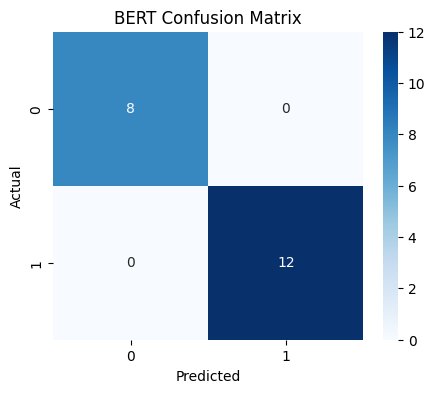

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("BERT Confusion Matrix")

plt.show()